# 3. Feature Engineering

En este notebook aplicamos codificaciones y escalados siguiendo la sección 2.3 de la lección.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, QuantileTransformer
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

## Muestra inicial
Una muestra rápida del DataFrame cargado.

In [3]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
666,0,2,male,25.0,0,0,13.0000,S
534,0,3,female,30.0,0,0,8.6625,S
621,1,1,male,42.0,1,0,52.5542,S
317,0,2,male,54.0,0,0,14.0000,S
630,1,1,male,80.0,0,0,30.0000,S


## Codificación de variables categóricas
Codificamos `Sex` y `Embarked` con LabelEncoder (no hacemos one-hot aquí).

In [4]:
le_sex = LabelEncoder()
le_emb = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'].astype(str))
df['Embarked'] = le_emb.fit_transform(df['Embarked'].astype(str))

## Muestra después de la codificación
Comprobamos que ya no quedan variables categóricas en `Sex` y `Embarked`.

In [5]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
803,1,3,1,0.42,0,1,8.5167,0
418,0,2,1,30.00,0,0,13.0000,2
529,0,2,1,23.00,2,1,11.5000,2
247,1,2,0,24.00,0,2,14.5000,2
379,0,3,1,19.00,0,0,7.7750,2


## Distribuciones originales de `Age` y `Fare`

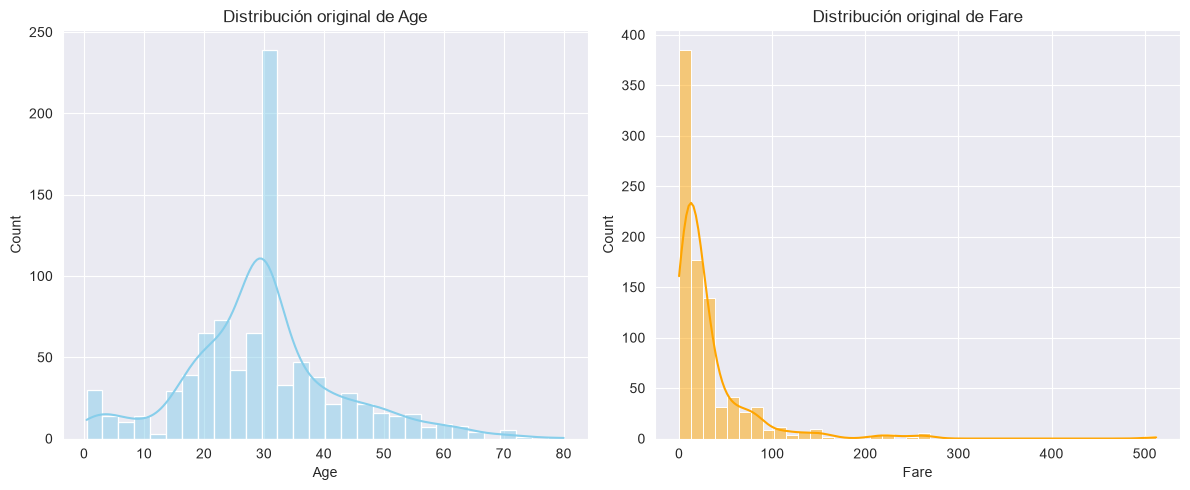

In [6]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribución original de Age')
plt.subplot(1,2,2)
sns.histplot(df['Fare'].dropna(), bins=40, kde=True, color='orange')
plt.title('Distribución original de Fare')
plt.tight_layout()
plt.show()

## Aplicar QuantileTransformer a `Age` y `Fare`
Usamos `output_distribution='normal'` y `n_quantiles=500`.

In [7]:
from sklearn.exceptions import NotFittedError
qt_age = QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
qt_fare = QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
# Transform only non-null values to preserve NaNs
age_mask = df['Age'].notna()
fare_mask = df['Fare'].notna()
if age_mask.sum() > 0:
    df.loc[age_mask, 'Age_qt'] = qt_age.fit_transform(df.loc[age_mask, ['Age']]).ravel()
if fare_mask.sum() > 0:
    df.loc[fare_mask, 'Fare_qt'] = qt_fare.fit_transform(df.loc[fare_mask, ['Fare']]).ravel()

## Distribuciones después de QuantileTransformer
Comparar las distribuciones transformadas.

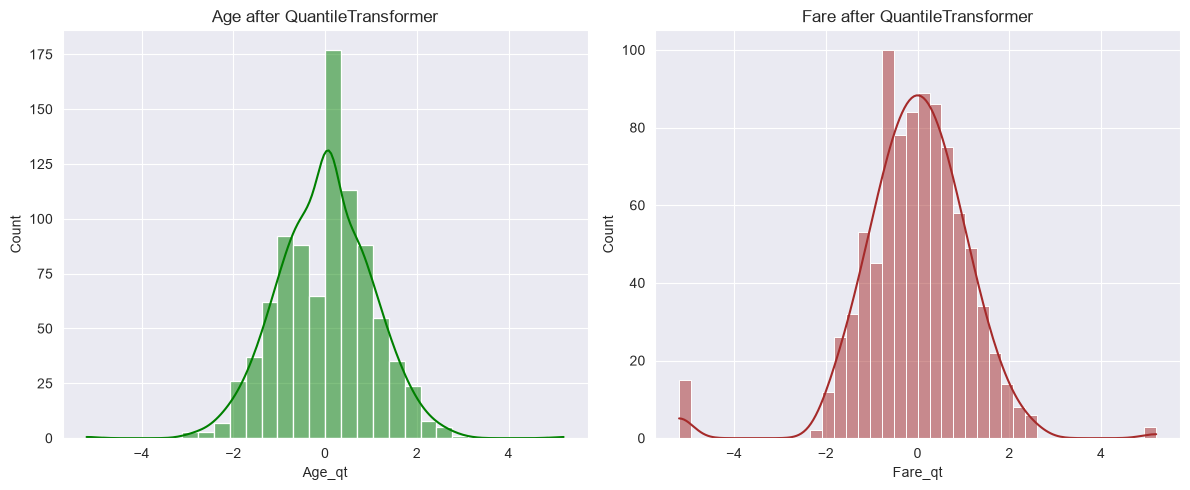

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Age_qt'].dropna(), bins=30, kde=True, color='green')
plt.title('Age after QuantileTransformer')
plt.subplot(1,2,2)
sns.histplot(df['Fare_qt'].dropna(), bins=40, kde=True, color='brown')
plt.title('Fare after QuantileTransformer')
plt.tight_layout()
plt.show()

## Aplicar MinMaxScaler a las columnas especificadas
Normalizamos las columnas indicadas individualmente. No transformamos `Survived`.

In [9]:
mms = MinMaxScaler()
cols_to_scale = ['Pclass','Sex','Age_qt','SibSp','Parch','Fare_qt','Embarked']
for col in cols_to_scale:
    vals = df[col].values.reshape(-1,1).astype(float)
    df[col + '_scaled'] = mms.fit_transform(vals).ravel()

## Muestra final del DataFrame transformado
Mostramos 5 registros del DataFrame ya procesado.

In [10]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_qt,Fare_qt,Pclass_scaled,Sex_scaled,Age_qt_scaled,SibSp_scaled,Parch_scaled,Fare_qt_scaled,Embarked_scaled
2,1,3,0,26.000000,0,0,7.925,2,-0.391550,-0.641740,1.0,0.0,0.462346,0.0,0.0,0.438286,1.0
302,0,3,1,19.000000,0,0,0.000,2,-0.956782,-5.199338,1.0,1.0,0.407990,0.0,0.0,0.000000,1.0
776,0,3,1,29.699118,0,0,7.750,1,0.075421,-1.092646,1.0,1.0,0.507253,0.0,0.0,0.394924,0.5
564,0,3,0,29.699118,0,0,8.050,2,0.075421,-0.537123,1.0,0.0,0.507253,0.0,0.0,0.448347,1.0
864,0,2,1,24.000000,0,0,13.000,2,-0.542935,-0.108212,0.5,1.0,0.447788,0.0,0.0,0.489594,1.0


In [11]:
# Guardar el DataFrame procesado en data/titanic_procesado.csv
df.to_csv('./data/titanic_procesado.csv', index=False)
print('Archivo ./data/titanic_procesado.csv guardado')

Archivo ./data/titanic_procesado.csv guardado
